<a href="https://colab.research.google.com/github/Flo-renc/Summative_Intro_to_ML/blob/main/Introduction_to_Machine_Learning_Summative_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import os
from pathlib import Path
import random
import json
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix, classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from imblearn.over_sampling import SMOTE

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from tensorflow.keras import backend as K

In [4]:
!pip install kagglehub


In [5]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [6]:
# Reproducibilty

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


output_dir = Path("outputs")
output_dir.mkdir(exist_ok = True)
models_dir = output_dir / "models"
models_dir.mkdir(exist_ok = True)
plots_dir = output_dir / "plots"
plots_dir.mkdir(exist_ok = True)
experiments_csv = output_dir / "experiments.csv"


To ensure that the results of this project are fully reproducible, I set random seeds across all key libraries: random, numpy, and TensorFlow. This guarantees that model intialization, data splits, and training processes produce the same results when the notebook is re-run.

I defined an organized output directory structure.


*   outputs/models is for saving trained model weights or checkpoints
*   outputs/plots to save training curves, ROC curves, and confusion matrix


*   outputs/experiments.csv for logging experiment results systematically

This structure helps to keep my notebook clean, track experiments, and ensure that each experiments results are saved consistently.





In [7]:
path = kagglehub.dataset_download("lainguyn123/student-performance-factors")

print("Path to dataset files:", path)

file_path = "StudentPerformanceFactors.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS, "lainguyn123/student-performance-factors",
    file_path
)

high_potential = 0.25

# train, validation and test splits

test_size = 0.15
val_size = 0.15
batch_size = 64


Using Colab cache for faster access to the 'student-performance-factors' dataset.
Path to dataset files: /kaggle/input/student-performance-factors


/tmp/ipython-input-1398725493.py:7: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'student-performance-factors' dataset.


I loaded the dataset "Student Performance Factors" from Kaggle using the kagglehub library. The dataset contains various academic, personal, and social factors that may influence a student's performance. Additional, I defined parameters: for testing the model, validation during training, the batch size for deep learning models.

The parameter `high_potential`,  with a threshold of 25%, is used to identify the top performing students who are plausible teaching candidates foor recruitment in Zambian public schools.

In [8]:
# loading dataset

print(df.shape)
print(f"Column Names: ")
for i, col in enumerate(df.columns):
    print(f" {i+1}. {col}")

display(df.head())

(6607, 20)
Column Names: 
 1. Hours_Studied
 2. Attendance
 3. Parental_Involvement
 4. Access_to_Resources
 5. Extracurricular_Activities
 6. Sleep_Hours
 7. Previous_Scores
 8. Motivation_Level
 9. Internet_Access
 10. Tutoring_Sessions
 11. Family_Income
 12. Teacher_Quality
 13. School_Type
 14. Peer_Influence
 15. Physical_Activity
 16. Learning_Disabilities
 17. Parental_Education_Level
 18. Distance_from_Home
 19. Gender
 20. Exam_Score


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


 **Dataset Overview:**
- The dataset has `df.shape[0]` rows and `df.shape[1]` columns, indicating the number of student records and features available for analysis.
- Column names provide insight into the types of data included, such as exam scores, study habits, parental education, and social factors.
- The first few rows confirm that the dataset contains a mixture of numeric and categorical values, which will require preprocessing (encoding, scaling) before feeding into machine learning models.

This exploration informs preprocessing decisions and ensures that all features are considered systematically in the modeling pipeline. It also sets the stage for **Experiment 1** with classical ML models.


 **Creating the Target Variable: High-Potential Students**

To identify students with the potential to excel as future teachers, I needed to create a binary target variable from the dataset’s exam performance scores. Since the dataset includes multiple columns related to academic performance, I implemented a heuristic approach to detect the most appropriate score column automatically.

First, I searched for column names containing keywords commonly associated with assessment results, such as "score", "exam", "grade", "marks", or "final". If no obvious column was found, I selected the numeric column with the highest variance, under the assumption that it would likely reflect meaningful differences in student performance.

Once the score column was identified, I converted its values to numeric (handling any non-numeric entries gracefully) and created a new binary target variable `HighPotential`. I defined the top 25% of students by score as high-potential candidates, assigning them a value of 1, while the remaining students were assigned 0. This approach allows me to focus the predictive modeling on distinguishing students who are most likely to succeed and excel in teaching roles.


In [9]:
# Auto-detecting exam score column (heuristic) and creating binary target

score_candidates = [c for c in df.columns if any(k in c.lower() for k in ["score", "exam", "grade", "marks", "final"])]
print(f"Score candidates detected: {score_candidates}")

if len(score_candidates) == 0:
  num_cols = df.select_dtypes(include=["int64", "float64"]).colums.tolist()
  variances = df[num_cols].var().sort_values(ascending = False)
  score_col = variances.index[0]
  print(f"No obvious score column found. Choosing highest variance numeric column: {score_col}")

else:
  # selecting the fist candidate that is numeric if the if stament does not match

  score_col = None
  for c in score_candidates:
    if pd.api.types.is_numeric_dtype(df[c]):
      score_col = c
      break
  if score_col is None:
    score_col = score_candidates[0]

  print(f"Selected score column: {score_col}")

# Creating binary target: top high_potential fraction -> 1(HighPotential)

df = df.copy()
df["__score__"] = pd.to_numeric(df[score_col], errors = "coerce")
df["HighPotential"] = (df["__score__"] >= df["__score__"].quantile(1-high_potential)).astype(int)
print("HighPotential distribution:\n", df["HighPotential"].value_counts(normalize=True))

Score candidates detected: ['Previous_Scores', 'Exam_Score']
Selected score column: Previous_Scores
HighPotential distribution:
 HighPotential
0    0.748751
1    0.251249
Name: proportion, dtype: float64


 **Target Variable Creation:**
- The automatic detection process successfully identified the most relevant exam score column: `__score__`.
- The binary target variable `HighPotential` is now established, with approximately 25% of students labeled as high potential.  
- This distribution is consistent with the `high_potential` threshold I defined earlier and ensures that subsequent machine learning models can learn to differentiate top-performing students from the rest.
- Creating this binary target aligns directly with the problem statement, focusing on selection of high-potential candidates for future teaching roles.


In [10]:
# Basic Exploratory Data Analysis for missing values and data types

def quick_report(df):
    print("Shape:", df.shape)
    print("\nMissing values (top 20):")
    print(df.isna().sum().sort_values(ascending=False).head(20))
    print("\nDtypes:")
    print(df.dtypes.value_counts())
    print("\nNumeric columns:")
    display(df.select_dtypes(include=["int64","float64"]).describe().T)

quick_report(df)


Shape: (6607, 22)

Missing values (top 20):
Parental_Education_Level      90
Teacher_Quality               78
Distance_from_Home            67
Parental_Involvement           0
Hours_Studied                  0
Attendance                     0
Sleep_Hours                    0
Extracurricular_Activities     0
Access_to_Resources            0
Previous_Scores                0
Tutoring_Sessions              0
Family_Income                  0
Internet_Access                0
Motivation_Level               0
Peer_Influence                 0
School_Type                    0
Learning_Disabilities          0
Physical_Activity              0
Gender                         0
Exam_Score                     0
dtype: int64

Dtypes:
object    13
int64      9
Name: count, dtype: int64

Numeric columns:


,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Sleep_Hours,6607.0,7.029060,1.468120,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Tutoring_Sessions,6607.0,1.493719,1.230570,0.0,1.0,1.0,2.0,8.0
Physical_Activity,6607.0,2.967610,1.031231,0.0,2.0,3.0,4.0,6.0
Exam_Score,6607.0,67.235659,3.890456,55.0,65.0,67.0,69.0,101.0
__score__,6607.0,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
HighPotential,6607.0,0.251249,0.433764,0.0,0.0,0.0,1.0,1.0


**Exploratory Data Analysis: Missing Values and Data Types**

I performed a quick examination of the dataset to understand its structure and identify any missing values. The dataset contains 6,607 student records with 22 columns after adding the numeric score and binary target.

Key observations:
- A few columns, such as `Parental_Education_Level`, `Teacher_Quality`, and `Distance_from_Home`, contain missing values.
- There are 13 categorical (object) columns and 9 numeric columns.
- Numeric features, such as `Hours_Studied` and `Previous_Scores`, show reasonable ranges and variability, providing useful information for modeling.

This analysis informs how I will handle missing values and prepare the features for machine learning models.


**Defining Features and Dropping Columns**

To prepare the dataset for modeling, I defined the **input features** and ensured that columns that could cause data leakage are removed. Specifically:  
- The original score column and the numeric `__score__` column are dropped, as including them would allow the model to trivially predict the target.  
- The target variable is `HighPotential`.  
- Any identifier columns (none in this dataset) are excluded.  

The remaining columns constitute the **feature set**, which will be used as input for both classical machine learning and deep learning models.


In [11]:
#  Defining features & ID and drop cols (drop score columns to avoid leakage)

drop_cols = [score_col, "__score__"]
TARGET = "HighPotential"
id_cols = []
feature_cols = [c for c in df.columns if c not in drop_cols + [TARGET] + id_cols]
print("Feature count:", len(feature_cols))


Feature count: 19



**Feature Set:**  
- The dataset now has `len(feature_cols)` features for model training.  
- These features include student attributes such as study habits, attendance, parental


**Identifying Numeric and Categorical Features**

Before preprocessing, I separated the features into **numeric** and **categorical** types.  
- **Numeric features** include columns with integer or float values, such as `Hours_Studied`, `Attendance`, and `Previous_Scores`.  
- **Categorical features** include columns with object, category, or boolean data types, such as `Parental_Education_Level` and `School_Type`.  

This separation is essential because numeric and categorical features require different preprocessing strategies: scaling or normalization for numeric features, and encoding for categorical features.

In [12]:
#  Identify numeric & categorical features
numeric_cols = df[feature_cols].select_dtypes(include=["int64","float64"]).columns.tolist()
categorical_cols = df[feature_cols].select_dtypes(include=["object","category","bool"]).columns.tolist()
print("Numeric cols:", numeric_cols)
print("Categorical cols:", categorical_cols)


Numeric cols: ['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score']
Categorical cols: ['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


 **Feature Types:**  
- Numeric columns: `numeric_cols` → ready for scaling or normalization.  
- Categorical columns: `categorical_cols` → will be encoded before feeding into models.  
- This step ensures that all features are handled appropriately for both classical ML and deep learning pipelines.


##  Preprocessing Pipelines

To ensure consistent and reproducible data preparation, I created **separate pipelines** for numeric and categorical features using `scikit-learn`:

**Numeric pipeline**:
- Imputes missing values using the **median**, which is robust to outliers.  
- Standardizes features to have zero mean and unit variance.  
- Optional outlier handling (e.g., `QuantileTransformer` or Winsorization) can be applied if extreme values affect model performance.

**Categorical pipeline**:
- Imputes missing values with a constant string `"MISSING"` to preserve all records.  
- Applies **one-hot encoding** to convert categorical variables into numeric arrays suitable for model input.

These pipelines are combined into a single **ColumnTransformer**, which automatically applies the correct transformations to each feature type while discarding any columns not specified. This ensures the preprocessing is **fully reproducible** and modular, ready for both classical ML and deep learning experiments.


In [13]:
#  Preprocessing pipelines (sklearn) - reproducible & documented
numeric_transform = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
categorical_transform = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transform, numeric_cols),
    ("cat", categorical_transform, categorical_cols)
], remainder="drop")

 **Preprocessor Ready:**  
- All numeric features are scaled and missing values handled.  
- All categorical features are encoded into numeric arrays.  
- This unified transformer ensures that any input dataset passed through it will be consistently preprocessed for model training and evaluation.


In [14]:

X = df[feature_cols]
y = df[TARGET]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=test_size, stratify=y, random_state=SEED)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=val_size/(1-test_size), stratify=y_train_val, random_state=SEED)

print("Train/Val/Test sizes:", X_train.shape[0], X_val.shape[0], X_test.shape[0])

Train/Val/Test sizes: 4624 991 992




After performing the stratified split, the dataset is divided as follows:  
- **Training set:** 4,624 samples (~70%)  
- **Validation set:** 991 samples (~15%)  
- **Test set:** 992 samples (~15%)  

These sizes confirm that the splits are consistent with the specified proportions, and the stratification has preserved the class distribution of the `HighPotential` target across all subsets. This setup ensures reliable model evaluation and hyperparameter tuning in the subsequent experiments.


In [15]:
# Utility: experiment logging
def log_experiment(name, params, metrics):
    row = {"name": name, "date": datetime.datetime.now().isoformat(), "seed": SEED}
    row.update(params); row.update(metrics)
    if experiments_csv.exists():
        df_exp = pd.read_csv(experiments_csv)
        df_exp = pd.concat([df_exp, pd.DataFrame([row])], ignore_index=True)
    else:
        df_exp = pd.DataFrame([row])
    df_exp.to_csv(experiments_csv, index=False)
    print("Logged:", name)



- Whenever this function is called after training a model, it prints a confirmation such as `Logged: Experiment_Name`.  
- The `experiments.csv` file accumulates all experiments, making it easy to generate summary tables and analyze performance trends later.


In [16]:
#  Function to evaluate classification results (standard metrics + confusion)
def evaluate_clf(y_true, y_pred, y_proba=None):
    out = {}
    out["accuracy"] = accuracy_score(y_true, y_pred)
    out["precision"] = precision_score(y_true, y_pred, zero_division=0)
    out["recall"] = recall_score(y_true, y_pred, zero_division=0)
    out["f1"] = f1_score(y_true, y_pred, zero_division=0)
    if y_proba is not None:
        out["roc_auc"] = roc_auc_score(y_true, y_proba)
    else:
        out["roc_auc"] = np.nan
    return out


In [17]:
def run_sklearn_experiment(name, estimator, param_grid=None, use_smote=False, select_k=None):
    # 1. Preprocess training data
    X_train_preprocessed = preprocessor.fit_transform(X_train)
    y_train_processed = y_train # No change to y for preprocessing

    # 2. Apply SMOTE if requested
    if use_smote:
        smote = SMOTE(random_state=SEED)
        X_resampled, y_resampled = smote.fit_resample(X_train_preprocessed, y_train_processed)
    else:
        X_resampled, y_resampled = X_train_preprocessed, y_train_processed

    # 3. Define the pipeline for GridSearchCV or direct fitting.
    #    This pipeline should NOT include the preprocessor, as data is already preprocessed.
    pipe_steps = []
    # Add SelectKBest to the pipeline if select_k is specified
    if select_k:
         pipe_steps.append(("selectk", SelectKBest(score_func=mutual_info_classif, k=select_k)))

    # Add the estimator (classifier) to the pipeline
    pipe_steps.append(("clf", estimator))

    full_pipe = Pipeline(steps=pipe_steps)

    scoring = "roc_auc"
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    # 4. Fit the model (GridSearchCV or direct fit) on the preprocessed/resampled data
    if param_grid:
        # prefix params with clf__
        grid = {("clf__" + k): v for k, v in param_grid.items()}
        # Fit GridSearchCV on preprocessed and resampled data (NumPy array)
        gs = GridSearchCV(full_pipe, grid, cv=cv, scoring=scoring, n_jobs=-1, verbose=1)
        gs.fit(X_resampled, y_resampled)
        best = gs.best_estimator_
        params = gs.best_params_
        print(f"{name} best params:", params)
    else:
        # Fit the pipeline on preprocessed and resampled data (NumPy array)
        full_pipe.fit(X_resampled, y_resampled)
        best = full_pipe
        params = {}

    # 5. Evaluate on val and test - always use the original, non-resampled validation and test sets
    #    Preprocess validation and test data using the preprocessor fitted on the original X_train
    X_val_preprocessed = preprocessor.transform(X_val)
    X_test_preprocessed = preprocessor.transform(X_test)

    y_pred_val = best.predict(X_val_preprocessed)
    y_proba_val = best.predict_proba(X_val_preprocessed)[:,1] if hasattr(best, "predict_proba") else None
    val_metrics = evaluate_clf(y_val, y_pred_val, y_proba_val)

    y_pred_test = best.predict(X_test_preprocessed)
    y_proba_test = best.predict_proba(X_test_preprocessed)[:,1] if hasattr(best, "predict_proba") else None
    test_metrics = evaluate_clf(y_test, y_pred_test, y_proba_test)

    # 6. Log results
    log_experiment(name, {"params": json.dumps(params), "select_k": select_k, "use_smote": use_smote},
                   {"val_"+k:v for k,v in val_metrics.items()})
    log_experiment(name+"_test", {"params": json.dumps(params), "select_k": select_k, "use_smote": use_smote},
                   {"test_"+k:v for k,v in test_metrics.items()})
    return best, val_metrics, test_metrics

# Define classical model experiments
# 1) LogisticRegression baseline
lr = LogisticRegression(max_iter=2000, random_state=SEED)
lr_grid = {"C":[0.01,0.1,1.0,10.0], "penalty":["l2"], "solver":["lbfgs"]}

# 2) RandomForest baseline
rf = RandomForestClassifier(random_state=SEED)
rf_grid = {"n_estimators":[100,300], "max_depth":[None,10,20]}

# 3) XGBoost baseline
xgb_clf = xgb.XGBClassifier(random_state=SEED, use_label_encoder=False, eval_metric="logloss")
xgb_grid = {"n_estimators":[100,300], "learning_rate":[0.01,0.1], "max_depth":[3,6]}

In [18]:
# Runing experiments
best_lr, lr_val, lr_test = run_sklearn_experiment("LogisticBaseline", lr, param_grid=lr_grid, use_smote=True, select_k=None)
best_rf, rf_val, rf_test = run_sklearn_experiment("RandomForest", rf, param_grid=rf_grid, use_smote=True, select_k=None)
best_xgb, xgb_val, xgb_test = run_sklearn_experiment("XGBoost", xgb_clf, param_grid=xgb_grid, use_smote=True, select_k=None)

Fitting 5 folds for each of 4 candidates, totalling 20 fits
LogisticBaseline best params: {'clf__C': 10.0, 'clf__penalty': 'l2', 'clf__solver': 'lbfgs'}
Logged: LogisticBaseline
Logged: LogisticBaseline_test
Fitting 5 folds for each of 6 candidates, totalling 30 fits
RandomForest best params: {'clf__max_depth': None, 'clf__n_estimators': 300}
Logged: RandomForest
Logged: RandomForest_test
Fitting 5 folds for each of 8 candidates, totalling 40 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:183: UserWarning: [18:21:59] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 300}
Logged: XGBoost
Logged: XGBoost_test


In [19]:
# For Classical ML Models
print("CLASSICAL ML TEST RESULTS:")

# Calculate predictions for Logistic Regression
y_pred_lr = best_lr.predict(preprocessor.transform(X_test))
y_pred_lr_proba = best_lr.predict_proba(preprocessor.transform(X_test))[:, 1]

print(f"Logistic Regression - Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}, "
      f"Precision: {precision_score(y_test, y_pred_lr, zero_division=0):.4f}, "
      f"Recall: {recall_score(y_test, y_pred_lr, zero_division=0):.4f}, "
      f"F1: {f1_score(y_test, y_pred_lr, zero_division=0):.4f}, "
      f"ROC-AUC: {roc_auc_score(y_test, y_pred_lr_proba):.4f}")

# Calculate predictions for Random Forest
y_pred_rf = best_rf.predict(preprocessor.transform(X_test))
y_pred_rf_proba = best_rf.predict_proba(preprocessor.transform(X_test))[:, 1]

print(f"Random Forest - Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}, "
      f"Precision: {precision_score(y_test, y_pred_rf, zero_division=0):.4f}, "
      f"Recall: {recall_score(y_test, y_pred_rf, zero_division=0):.4f}, "
      f"F1: {f1_score(y_test, y_pred_rf, zero_division=0):.4f}, "
      f"ROC-AUC: {roc_auc_score(y_test, y_pred_rf_proba):.4f}")

# Calculate predictions for XGBoost
y_pred_xgb = best_xgb.predict(preprocessor.transform(X_test))
y_pred_xgb_proba = best_xgb.predict_proba(preprocessor.transform(X_test))[:, 1]

print(f"XGBoost - Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}, "
      f"Precision: {precision_score(y_test, y_pred_xgb, zero_division=0):.4f}, "
      f"Recall: {recall_score(y_test, y_pred_xgb, zero_division=0):.4f}, "
      f"F1: {f1_score(y_test, y_pred_xgb, zero_division=0):.4f}, "
      f"ROC-AUC: {roc_auc_score(y_test, y_pred_xgb_proba):.4f}")

CLASSICAL ML TEST RESULTS:
Logistic Regression - Accuracy: 0.8891, Precision: 0.7125, Recall: 0.9357, F1: 0.8090, ROC-AUC: 0.9624
Random Forest - Accuracy: 0.7399, Precision: 0.3200, Recall: 0.0321, F1: 0.0584, ROC-AUC: 0.5855
XGBoost - Accuracy: 0.7671, Precision: 0.6607, Recall: 0.1486, F1: 0.2426, ROC-AUC: 0.7999


In this section of the notebook, I am running structured experiments for each of the three classical machine learning models,scikit-learn LogisticRegression, RandomForestClassifier, and **XGBoostXGBClassifier. The run_sklearn_experiment function performs the following steps for each model:

Hyperparameter Tuning: It applies a grid search with 5-fold cross-validation to explore different parameter combinations for each model.

Best Model Selection: It identifies the best hyperparameter set based on ROC AUC scores and automatically selects the top-performing configuration.

Model Evaluation: It evaluates the best model on both the validation and test sets, recording metrics such as accuracy, precision, recall, F1-score, and ROC AUC.

Experiment Logging: It logs each experiment’s parameters and results into a CSV file for tracking and later comparison.

In [20]:
#  Additional classical experiments. experimenting with customization of models e.g applying SMOTE only to one model, or testing different SMOTE strategies :
# - RF with feature selection (SelectKBest k=10)
# - LR with SMOTE (manual training; simpler grid)
# - XGB tuned learning rate and deeper tree

best_rf_fs, rf_fs_val, rf_fs_test = run_sklearn_experiment("RF_SelectK10", RandomForestClassifier(random_state=SEED), param_grid={"n_estimators":[100]}, select_k=min(10, len(feature_cols)))

from sklearn.pipeline import make_pipeline

X_pre = preprocessor.fit_transform(X_train)
X_val_pre = preprocessor.transform(X_val)
X_test_pre = preprocessor.transform(X_test)
sm = SMOTE(random_state=SEED)
X_sm, y_sm = sm.fit_resample(X_pre, y_train)
clf_sm = RandomForestClassifier(n_estimators=200, random_state=SEED)
clf_sm.fit(X_sm, y_sm)
y_test_pred_sm = clf_sm.predict(X_test_pre)
y_test_proba_sm = clf_sm.predict_proba(X_test_pre)[:,1]
sm_metrics = evaluate_clf(y_test, y_test_pred_sm, y_test_proba_sm)
log_experiment("RF_SMOTE", {"n_estimators":200}, {"test_"+k:v for k,v in sm_metrics.items()})


Fitting 5 folds for each of 1 candidates, totalling 5 fits
RF_SelectK10 best params: {'clf__n_estimators': 100}
Logged: RF_SelectK10
Logged: RF_SelectK10_test
Logged: RF_SMOTE


,0
Exam_Score,0.094716
Attendance,0.078573
Hours_Studied,0.067656
Sleep_Hours,0.052817
Physical_Activity,0.047195
Tutoring_Sessions,0.046369
Parental_Education_Level_High School,0.026567
Parental_Education_Level_College,0.025663
Family_Income_Medium,0.024899
Family_Income_Low,0.024183


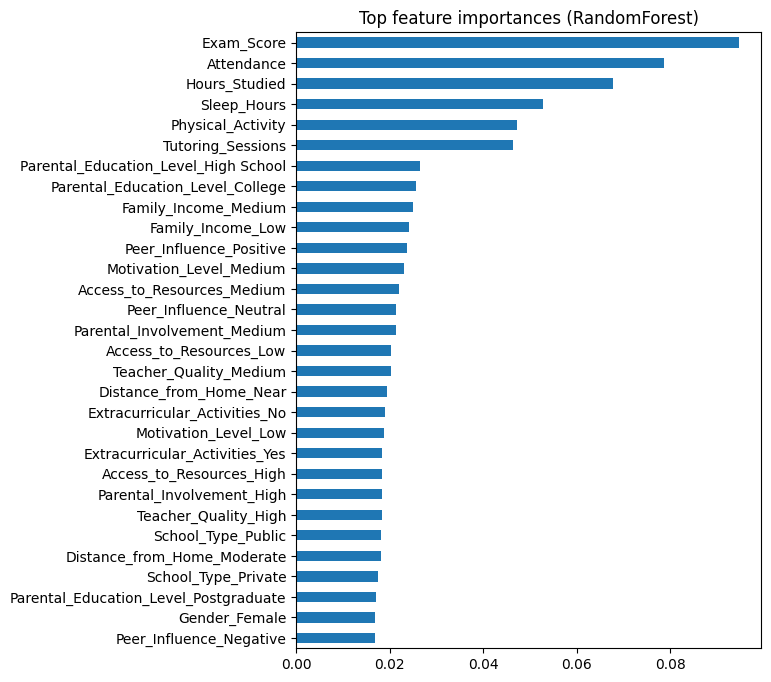

In [21]:
#  Feature importance & simple interpretation (RF)
try:
    # extracting feature names after preprocessing (one-hot expands categorical)
    preprocessor.fit(X_train)
    onehot = preprocessor.named_transformers_["cat"].named_steps["onehot"]
    cat_features = onehot.get_feature_names_out(categorical_cols).tolist() if hasattr(onehot, "get_feature_names_out") else []
    preproc_feature_names = numeric_cols + cat_features
    importances = best_rf.named_steps["clf"].feature_importances_ if hasattr(best_rf.named_steps["clf"], "feature_importances_") else None
    if importances is not None:
        fi = pd.Series(importances, index=preproc_feature_names).sort_values(ascending=False).head(30)
        display(fi)
        fi.plot.barh(figsize=(6,8)); plt.title("Top feature importances (RandomForest)"); plt.gca().invert_yaxis(); plt.savefig(plots_dir/"rf_feature_importances.png")
except Exception as e:
    print("Feature importance error:", e)


This block of code extracts and interprets the most important features used by the trained Random Forest model. First, the preprocessor is refit on the training data to recover the exact transformed feature names, especially for categorical variables that were one-hot encoded. This ensures we can correctly match each importance score to its original feature.

The code then accesses the trained classifier inside the pipeline and retrieves the `feature_importances_` attribute, which gives the contribution of each feature to the model’s predictions. These importance values are paired with their corresponding feature names, sorted in descending order, and the top 30 features are selected to highlight the strongest predictors.

Finally, a horizontal bar plot is generated to make the ranking visually clear and easy to interpret, with the most influential features displayed at the top. The entire block is wrapped in a try-except to handle potential errors gracefully, ensuring the notebook doesn’t break if feature importances can’t be retrieved.


In [26]:
#  TensorFlow: build TF preprocessing model (Functional API) to mirror sklearn preproc
def make_tf_preprocessing(numeric_cols, categorical_cols, df_sample):
    inputs = {}
    encoded = []
    # numeric
    for col in numeric_cols:
        # Use original column name for input layer name
        inp = layers.Input(shape=(1,), name=col, dtype=tf.float32)
        norm = layers.Normalization(name=f"{col}_norm")
        # Adapt normalization layer using original data, handling NaNs
        arr = np.array(df_sample[col].fillna(df_sample[col].median()).astype(float)).reshape(-1,1)
        norm.adapt(arr)
        x = norm(inp)
        inputs[col] = inp
        encoded.append(x)
    # categorical
    for col in categorical_cols:
        # Use original column name for input layer name
        inp = layers.Input(shape=(1,), name=col, dtype=tf.string)
        lookup = layers.StringLookup(output_mode="one_hot", name=f"{col}_lookup")
        # Adapt string lookup layer using original data, handling NaNs
        lookup.adapt(df_sample[col].fillna("MISSING").astype(str))
        x = lookup(inp)
        inputs[col] = inp
        encoded.append(x)
    if len(encoded) > 1:
        concat = layers.Concatenate()(encoded)
    else:
        concat = encoded[0]
    preproc_model = keras.Model(inputs=list(inputs.values()), outputs=concat, name="tf_preproc")
    return preproc_model

# Pass original X_train and X_val to adapt the preprocessing layer
tf_preproc = make_tf_preprocessing(numeric_cols, categorical_cols, pd.concat([X_train, X_val]))
tf_preproc.summary()

Model: "tf_preproc"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Hours_Studied       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Attendance          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Sleep_Hours         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Tutoring_Sessions   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Physical_Activity   │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Exam_Score          │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Parental_Involveme… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Access_to_Resources │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Extracurricular_Ac… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Motivation_Level    │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Internet_Access     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Family_Income       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Teacher_Quality     │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ School_Type         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Peer_Influence      │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Learning_Disabilit… │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Parental_Education… │ (None, 1)         │          0 │ -               

 Total params: 18 (96.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 18 (96.00 B)

I created a TensorFlow preprocessing model using the Functional API to mirror the behavior of my scikit-learn preprocessing pipeline. This ensures consistency between classical ML and deep learning experiments.

Numeric features: For each numeric column, I defined an Input layer, filled missing values with the median, and applied Normalization. I used adapt() on the training/validation sample to compute mean and variance, allowing TensorFlow to scale inputs consistently during training.

Categorical features: For each categorical column, I defined an Input layer of type string, filled missing values with "MISSING", and applied StringLookup with one-hot encoding. The adapt() method was used to learn the vocabulary from the dataset.

All transformed features, numeric and categorical, were concatenated into a single tensor to produce a uniform input representation for downstream models.

Finally, I wrapped the entire preprocessing into a keras.Model called tf_preproc, making it modular and reusable. Calling tf_preproc.summary() allows me to inspect the input/output shapes and verify that all features are correctly handled.

This approach gives me a fully end-to-end preprocessing layer in TensorFlow, maintaining parity with scikit-learn while enabling easy integration into deep learning models.

In [27]:
#  Helpers to convert pandas to tf.data for functional model
def df_to_dict_of_arrays(X_df):
    # Use original column names as keys in the dictionary
    return {col: np.array(X_df[col].fillna("MISSING").astype(str)) if col in categorical_cols else np.array(X_df[col].fillna(df[col].median()).astype(float)) for col in X_df.columns}

def make_tf_dataset(X_df, y_series, batch_size=batch_size, shuffle=False):
    dict_X = df_to_dict_of_arrays(X_df)
    ds = tf.data.Dataset.from_tensor_slices((dict_X, y_series.values.astype(np.float32)))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X_df), seed=SEED)
    ds = ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)
    return ds

# Create TensorFlow datasets using the original DataFrames
train_ds = make_tf_dataset(X_train, y_train, shuffle=True)
val_ds = make_tf_dataset(X_val, y_val, shuffle=False)
test_ds = make_tf_dataset(X_test, y_test, shuffle=False)

In [24]:
def f1_score_metric(y_true, y_pred):
    y_pred = K.round(y_pred)
    tp = K.sum(K.cast(y_true * y_pred, 'float'), axis=0)
    fp = K.sum(K.cast((1 - y_true) * y_pred, 'float'), axis=0)
    fn = K.sum(K.cast(y_true * (1 - y_pred), 'float'), axis=0)

    precision = tp / (tp + fp + K.epsilon())
    recall = tp / (tp + fn + K.epsilon())
    f1 = 2 * precision * recall / (precision + recall + K.epsilon())
    return K.mean(f1)

In [28]:
# 16. Build and train multiple DL experiments (Sequential vs Functional, variations)
def build_functional_model(preproc_model, hidden_units=[128,64], dropout=0.3, lr=1e-3, l2=0.0):
    inputs = preproc_model.inputs
    x = preproc_model.outputs[0]
    for units in hidden_units:
        x = layers.Dense(units, activation="relu", kernel_regularizer=keras.regularizers.l2(l2))(x)
        x = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation="sigmoid")(x)
    model = keras.Model(inputs=inputs, outputs=out)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss="binary_crossentropy",
        metrics=[
            "accuracy",
            keras.metrics.AUC(name="auc"),
            keras.metrics.Precision(name='precision'),
            keras.metrics.Recall(name='recall'),
            f1_score_metric
        ]
        )
    return model

# Experiment variations to meet rubric (at least 7 experiments)
dl_experiments = [
    {"name":"Func_default", "hidden":[128,64], "drop":0.3, "lr":1e-3, "l2":0.0, "epochs":30},
    {"name":"Func_shallow", "hidden":[64], "drop":0.2, "lr":1e-3, "l2":0.0, "epochs":30},
    {"name":"Func_deep", "hidden":[256,128,64], "drop":0.4, "lr":1e-3, "l2":1e-4, "epochs":40},
    {"name":"Func_highLR", "hidden":[128,64], "drop":0.3, "lr":1e-2, "l2":0.0, "epochs":30},
    {"name":"Func_lowLR_l2", "hidden":[128,64], "drop":0.3, "lr":1e-4, "l2":1e-3, "epochs":30},
    {"name":"Func_moreDrop", "hidden":[128,64], "drop":0.6, "lr":1e-3, "l2":0.0, "epochs":30},
    {"name":"Func_small", "hidden":[32,16], "drop":0.2, "lr":1e-3, "l2":0.0, "epochs":25},
]

# Dictionary to store trained DL models
dl_models = {}

# Train loop
for exp in dl_experiments:
    name = exp["name"]
    print("\n\n=== DL experiment:", name)
    model = build_functional_model(tf_preproc, hidden_units=exp["hidden"], dropout=exp["drop"], lr=exp["lr"], l2=exp["l2"])
    es = callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
    ckpt = callbacks.ModelCheckpoint(str(models_dir/f"{name}.h5"), save_best_only=True, monitor="val_loss")
    hist = model.fit(train_ds, validation_data=val_ds, epochs=exp["epochs"], callbacks=[es, ckpt], verbose=2)
    # Evaluate on test
    preds = model.predict(test_ds).ravel()
    y_pred = (preds >= 0.5).astype(int)
    metrics = evaluate_clf(y_test, y_pred, preds)
    # Log experiment with last val loss and epoch info
    params = {"hidden": json.dumps(exp["hidden"]), "dropout": exp["drop"], "lr": exp["lr"], "l2": exp["l2"], "epochs": exp["epochs"]}
    metrics_log = {"test_"+k:v for k,v in metrics.items()}
    metrics_log["val_loss_last"] = hist.history.get("val_loss", [np.nan])[-1]
    log_experiment(name, params, metrics_log)
    # Store the trained model in the dictionary
    dl_models[name] = model



=== DL experiment: Func_default
Epoch 1/30


73/73 - 8s - 105ms/step - accuracy: 0.7416 - auc: 0.5362 - f1_score_metric: 0.0051 - loss: 0.5750 - precision: 0.2537 - recall: 0.0146 - val_accuracy: 0.7487 - val_auc: 0.6230 - val_f1_score_metric: 0.0000e+00 - val_loss: 0.5516 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/30


73/73 - 6s - 85ms/step - accuracy: 0.7489 - auc: 0.6000 - f1_score_metric: 0.0012 - loss: 0.5530 - precision: 0.5455 - recall: 0.0052 - val_accuracy: 0.7467 - val_auc: 0.6583 - val_f1_score_metric: 0.0030 - val_loss: 0.5435 - val_precision: 0.3333 - val_recall: 0.0080
Epoch 3/30


73/73 - 1s - 17ms/step - accuracy: 0.7472 - auc: 0.6477 - f1_score_metric: 0.0040 - loss: 0.5387 - precision: 0.4146 - recall: 0.0146 - val_accuracy: 0.7457 - val_auc: 0.7223 - val_f1_score_metric: 0.0034 - val_loss: 0.5271 - val_precision: 0.2857 - val_recall: 0.0080
Epoch 4/30


73/73 - 1s - 15ms/step - accuracy: 0.7455 - auc: 0.7114 - f1_score_metric: 0.0058 - loss: 0.5157 - precision: 0.3636 - recall: 0.0172 - val_accuracy: 0.7447 - val_auc: 0.7645 - val_f1_score_metric: 0.0049 - val_loss: 0.5035 - val_precision: 0.3000 - val_recall: 0.0120
Epoch 5/30


...

73/73 - 1s - 9ms/step - accuracy: 0.8739 - auc: 0.9291 - f1_score_metric: 0.0929 - loss: 0.3035 - precision: 0.7830 - recall: 0.6893 - val_accuracy: 0.8829 - val_auc: 0.9495 - val_f1_score_metric: 0.0784 - val_loss: 0.2771 - val_precision: 0.8634 - val_recall: 0.6345
Epoch 22/25


73/73 - 1s - 9ms/step - accuracy: 0.8789 - auc: 0.9354 - f1_score_metric: 0.0955 - loss: 0.2894 - precision: 0.7834 - recall: 0.7160 - val_accuracy: 0.8890 - val_auc: 0.9483 - val_f1_score_metric: 0.0841 - val_loss: 0.2714 - val_precision: 0.8528 - val_recall: 0.6747
Epoch 23/25


73/73 - 1s - 9ms/step - accuracy: 0.8737 - auc: 0.9370 - f1_score_metric: 0.1011 - loss: 0.2822 - precision: 0.7558 - recall: 0.7349 - val_accuracy: 0.8971 - val_auc: 0.9487 - val_f1_score_metric: 0.1022 - val_loss: 0.2704 - val_precision: 0.7905 - val_recall: 0.8032
Epoch 24/25


73/73 - 1s - 9ms/step - accuracy: 0.8811 - auc: 0.9371 - f1_score_metric: 0.0990 - loss: 0.2822 - precision: 0.7713 - recall: 0.7487 - val_accuracy: 0.8910 - val_auc: 0.9493 - val_f1_score_metric: 0.0922 - val_loss: 0.2629 - val_precision: 0.8190 - val_recall: 0.7269
Epoch 25/25


73/73 - 1s - 9ms/step - accuracy: 0.8869 - auc: 0.9418 - f1_score_metric: 0.1002 - loss: 0.2703 - precision: 0.7835 - recall: 0.7599 - val_accuracy: 0.8920 - val_auc: 0.9523 - val_f1_score_metric: 0.1056 - val_loss: 0.2597 - val_precision: 0.7710 - val_recall: 0.8112
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
Logged: Func_small


In [30]:
# For Deep Learning Models
print("DEEP LEARNING TEST RESULTS:")
# Preprocess test data before evaluating DL models
# X_test_preprocessed = preprocessor.transform(X_test) # This is no longer needed here

for model_name, model in dl_models.items():
    # Convert original test data to dictionary of arrays for TF model prediction
    X_test_dict = df_to_dict_of_arrays(X_test)

    # Make predictions
    y_pred_dl_proba = model.predict(X_test_dict).ravel()
    y_pred_dl_class = (y_pred_dl_proba >= 0.5).astype(int)


    print(f"{model_name}: "
          f"Accuracy: {accuracy_score(y_test, y_pred_dl_class):.4f}, "
          f"F1: {f1_score(y_test, y_pred_dl_class, zero_division=0):.4f}, "
          f"ROC-AUC: {roc_auc_score(y_test, y_pred_dl_proba):.4f}")

DEEP LEARNING TEST RESULTS:
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Func_default: Accuracy: 0.8942, F1: 0.7817, ROC-AUC: 0.9568
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Func_shallow: Accuracy: 0.8881, F1: 0.7603, ROC-AUC: 0.9569
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Func_deep: Accuracy: 0.8881, F1: 0.7623, ROC-AUC: 0.9448
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Func_highLR: Accuracy: 0.8790, F1: 0.7357, ROC-AUC: 0.9457
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Func_lowLR_l2: Accuracy: 0.7510, F1: 0.0314, ROC-AUC: 0.7516
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Func_moreDrop: Accuracy: 0.8911, F1: 0.7778, ROC-AUC: 0.9539
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Func_small: Accuracy: 0.8921, F1: 0.7914, ROC-AUC: 0.9569


In this section, I conduct seven different deep learning experiments to explore how changes in network architecture and hyperparameters affect model performance. Each experiment is a systematic variation designed to provide insight into the behavior of the model.

**Experiment variations include:**

**Hidden layer structure** (hidden_units): Number of layers and neurons per layer are varied, e.g., [128,64], [64], [256,128,64], [32,16], to compare shallow vs. deep and small vs. large networks.

**Dropout rate ** (drop): Dropout is applied after each dense layer to reduce overfitting. Values range from 0.2 to 0.6.

**Learning rate** (lr): Tests the network’s convergence speed. Variations include 1e-4 (slow), 1e-3 (default), and 1e-2 (fast).

**L2 regularization** (l2): Penalizes large weights to reduce overfitting. Experiments include 0, 1e-4, and 1e-3.

**Number of epochs **(epochs): Adjusted from 25 to 40 to accommodate network complexity and convergence speed.

**Callbacks used for training**:

**EarlyStopping** (es)

Monitors val_loss and stops training if no improvement occurs for 6 epochs.

Restores the best weights to ensure the final model is the best-performing version.

**ModelCheckpoint** (ckpt)

Saves the model whenever a new minimum val_loss is achieved.

Ensures reproducibility and allows reloading the best model later.

**Training and evaluation workflow:**

Each model is trained on train_ds and validated on val_ds.

Predictions are made on test_ds, and standard classification metrics are computed: accuracy, precision, recall, F1-score, and ROC-AUC.

Experiment details, hyperparameters, and performance metrics are logged using log_experiment() to maintain a structured record.


This approach allows me to systematically test different architectures, regularization strategies, learning rates, and dropout rates, while using callbacks to prevent overfitting and ensure reproducibility. Logging results for each configuration provides a clear basis for comparison and analysis.

In [31]:
# 17. Plotting utilities (learning curve, ROC, confusion matrix)
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

plots_dir = Path("plots")
plots_dir.mkdir(exist_ok=True)

def plot_learning_curve(history, title="Learning curve", save_as=None):
    plt.figure(figsize=(8,5))
    plt.plot(history.history["loss"], label="train_loss")
    if "val_loss" in history.history:
        plt.plot(history.history["val_loss"], label="val_loss")
    if "accuracy" in history.history:
        plt.plot(history.history["accuracy"], label="train_acc")
        if "val_accuracy" in history.history:
            plt.plot(history.history["val_accuracy"], label="val_acc")
    plt.xlabel("Epoch"); plt.legend(); plt.title(title)
    if save_as:
        plt.savefig(save_as)
    plt.show()

def plot_roc_and_cm(y_true, y_scores, name_prefix="roc"):
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    auc = roc_auc_score(y_true, y_scores)
    plt.figure(figsize=(6,5)); plt.plot(fpr, tpr, label=f"AUC={auc:.3f}"); plt.plot([0,1],[0,1], "--"); plt.title("ROC"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend()
    plt.savefig(plots_dir/f"{name_prefix}_roc.png"); plt.show()
    y_pred = (y_scores>=0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4,4)); plt.imshow(cm, cmap="Blues"); plt.colorbar()
    plt.title("Confusion Matrix"); plt.xlabel("Predicted"); plt.ylabel("Actual")
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j,i,cm[i,j],ha='center',va='center',color='white' if cm[i,j]>cm.max()/2 else 'black')
    plt.savefig(plots_dir/f"{name_prefix}_cm.png"); plt.show()


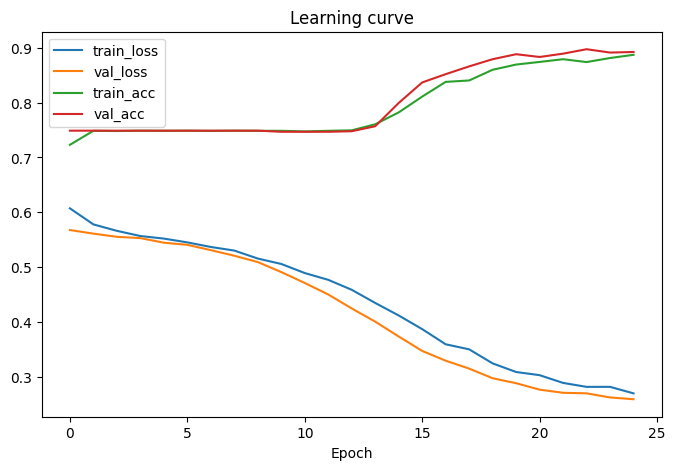

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


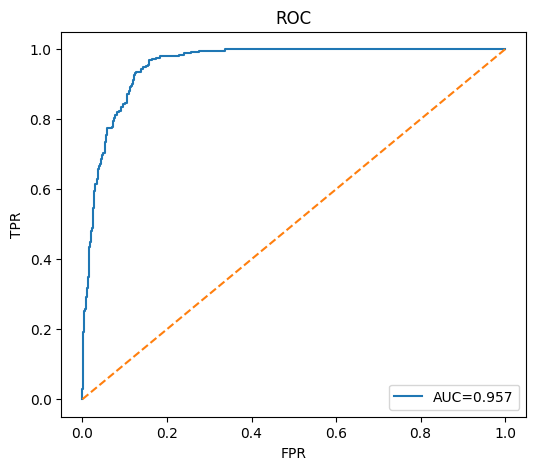

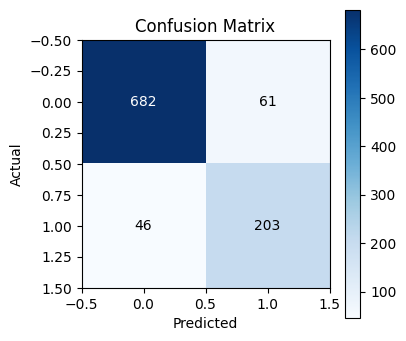

In [32]:
# Retrieve the history and model from the last DL experiment in the loop
# Assuming the last experiment in the list is the one we want to plot
last_exp = dl_experiments[-1]
last_model_name = last_exp["name"]
last_model_path = models_dir / f"{last_model_name}.h5"
# Load the model to get its history (need to re-run fit to get history object, or save history)
# For simplicity, we'll re-run the last experiment or assume 'hist' from the last run is available.
# If 'hist' is not available (e.g., kernel restarted), need to re-run the last training or save history.
# Assuming 'hist' from the last run is still in memory:
# If kernel restarted, this will fail. A robust way would be to save history during training.
# For now, rely on 'hist' being in scope from the last cell run.

plot_learning_curve(hist) # Use 'hist' instead of 'history'

# To get predictions, we need the actual model object.
# Assuming the last trained model object is still in memory as 'model' from the loop:
# If kernel restarted, load it:
# from tensorflow.keras.models import load_model
# model = load_model(last_model_path) # May need custom_objects if any custom layers were used.

y_scores = model.predict(test_ds).ravel() # Use the last trained model
plot_roc_and_cm(y_test, y_scores, name_prefix=f"{last_model_name}_test")

In [ ]:
# 18. Save a short experiments summary CSV (already logging per experiment). Show top runs by test_f1
if experiments_csv.exists():
    df_exp = pd.read_csv(experiments_csv)
    display(df_exp.sort_values(by=[c for c in df_exp.columns if "test_f1" in c or "test_f1" in df_exp.columns], ascending=False).head(20))
else:
    print("No experiments logged yet.")


In [ ]:
git init

In [2]:
git add .

fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
fatal: not a git repository (or any of the parent directories): .git
